In [ ]:
## importing packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from astropy import units as u
from astropy.coordinates import Longitude, Latitude, Angle
from astropy.io import fits
from astroquery.simbad import Simbad
from astroquery.hips2fits import hips2fits

In [ ]:
## package installation

# uncomment the below line if the above cell throws an error
# %pip install numpy pandas matplotlib astropy astroquery

# Data Extraction

In [ ]:
## obtaining the target celestial bodies' coordinates and types, and storing them in a dataframe

# list of query-able IDs
target_ids = ['HIP_27989', 'HIP_32349', 'HIP_91262', 'M31'] # test - betelgeuse, sirius, vega, andromeda galaxy
# TODO: assemble list of celestial bodies to survey

# right ascension (RA) and declination (dec) for target celestial bodies
target_coords = Simbad.query_objects(target_ids)['main_id', 'ra', 'dec']

# determines if celestial body is a star or a galaxy based on the id of the object
target_coords['type'] = [None] * len(target_coords)
for i in range(len(target_coords)):
    if (target_coords['main_id'][i][0] == '*'):
        target_coords['type'][i] = 'star'
    else: 
        target_coords['type'][i] = 'galaxy'

# sanity check
print(target_coords)

 main_id          ra                dec          type 
                 deg                deg               
--------- ------------------ ------------------ ------
* alf Ori  88.79293899077537  7.407063995272694   star
* alf CMa 101.28715533333335 -16.71611586111111   star
* alf Lyr   279.234734787025    38.783688956244   star
    M  31 10.684708333333333 41.268750000000004 galaxy


In [ ]:
# a function to get the hips image as a PNG from the right ascension (RA) and declination (Dec) 
# of a celestial body.
#
# parameters:
#   ra: RA in degrees
#   dec: Dec in degrees
#
# returns: 
#   np.ndarray of the HIPS image as a PNG


HIPS = 'CDS/P/PanSTARRS/DR1/color-z-zg-g'
WIDTH = 1000
HEIGHT = 1000
PROJECTION = 'TAN'
FORMAT = 'png'

def get_hips_image(ra, dec):
   result = hips2fits.query(
      hips=HIPS,
      width=WIDTH,
      height=HEIGHT,
      projection=PROJECTION,
      ra=Longitude(ra * u.deg),
      dec=Latitude(dec * u.deg),
      fov=Angle(1 * u.deg),
      format=FORMAT
   )
   return result

In [ ]:
## obtain images for target celestial bodies from RA and dec

images = {}

# loop to obtain images for previously defined target celestial bodies
for i in range(len(target_coords)):
   if (target_ids[i] not in images.keys()):
      images[target_ids[i]] = get_hips_image(target_coords[i]['ra'], target_coords[i]['dec'])

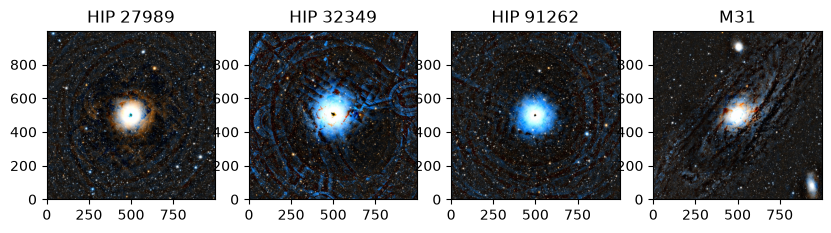

<Figure size 800x800 with 0 Axes>

In [40]:
## display image

# display images all at once for testing
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 4))

# iterate through each celestial body for each subplot
for i in range(len(target_ids)):
   axes[i].imshow(images[target_ids[i]], origin='lower') # color img display
   axes[i].set_title(' '.join(target_ids[i].split('_'))) # replace underscores with spaces

plt.figure(figsize=(8, 8))
plt.tight_layout()
plt.show()

In [ ]:
## image processing:
# for each, determine what is in it (star, galaxy...) based on name data/img analysis (large bright dot vs many small bright dots)
# star -> determine color of star
# galaxy/star cluster -> determine number of stars